In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Gör graferna snyggare
plt.style.use('ggplot') 

DATA_FILE = 'golf_rundor.csv'

def initialisera_data():
    if os.path.exists(DATA_FILE):
        df = pd.read_csv(DATA_FILE)
        print(f"Hittade {len(df)} sparade rundor.")
    else:
        df = pd.DataFrame(columns=['Datum', 'Bana', 'Tee', 'Slag', 'HCP'])
        df.to_csv(DATA_FILE, index=False)
        print("Ny databas skapad!")
    return df

df = initialisera_data()

Ny databas skapad!


In [2]:
def lagg_till_runda(datum, bana, tee, slag, hcp):
    global df
    ny_runda = {'Datum': datum, 'Bana': bana, 'Tee': tee, 'Slag': int(slag), 'HCP': float(hcp)}
    df = pd.concat([df, pd.DataFrame([ny_runda])], ignore_index=True)
    df.to_csv(DATA_FILE, index=False)
    print(f"Sparat! Du slog {slag} slag på {bana}.")

In [24]:
def rita_utveckling():
    if df.empty:
        print("Ingen data än.")
        return

    plt.figure(figsize=(12, 6))
    
    # Förbered data
    x = np.arange(1, len(df) + 1)
    y = df['Slag'].values
    snitt = np.mean(y)
    
    # 1. Rita linjen i segment som byter färg
    # Vi loopar igenom alla punkter utom den sista
    for i in range(len(x) - 1):
        # Vi kollar snittet mellan två punkter för att bestämma färg på linjesegmentet
        mellan_varde = (y[i] + y[i+1]) / 2
        linje_farg = '#2ecc71' if mellan_varde <= snitt else '#e74c3c'
        
        plt.plot([x[i], x[i+1]], [y[i], y[i+1]], 
                 color=linje_farg, linewidth=1, zorder=1)

    # 2. Hitta bästa och sämsta runda
    basta_score = np.min(y)
    samsta_score = np.max(y)
    
    # 3. Rita punkterna (plupparna) med villkorlig färg
    for i in range(len(x)):
        punkt_farg = '#2ecc71' if y[i] <= snitt else '#e74c3c'
        storlek = 40
        kantfarg = 'none'
        
        if y[i] == basta_score:
            punkt_farg = 'gold'
            storlek = 70
            kantfarg = 'gold'
        elif y[i] == samsta_score:
            punkt_farg = 'red'
            storlek = 70
            kantfarg = 'red'

        plt.scatter(x[i], y[i], color=punkt_farg, s=storlek, edgecolors=kantfarg, zorder=2)

    # 4. Snittlinjen (nu i blått för att bryta av)
    plt.axhline(snitt, color='blue', linestyle='--', linewidth=0.8, label=f'Snitt: {snitt:.1f}', zorder=0)
    
    # Inställningar för axlar
    plt.ylim(70, 130)
    plt.xlim(1, 50)
    plt.xticks([1] + list(np.arange(5, 51, 5)))
    
    plt.xlabel('Antal rundor')
    plt.ylabel('Antal slag')
    plt.title('Golfanalys - Dynamisk färgsättning')
    
    # Anpassad legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='blue', linestyle='--', lw=1, label=f'Snitt: {snitt:.1f}'),
        Line2D([0], [0], color='#2ecc71', lw=2, label='Bra trend (Under snitt)'),
        Line2D([0], [0], color='#e74c3c', lw=2, label='Sämre trend (Över snitt)'),
        Line2D([0], [0], marker='o', color='w', label='Bästa runda', markerfacecolor='gold', markeredgecolor='gold', markersize=6),
        Line2D([0], [0], marker='o', color='w', label='Sämsta runda', markerfacecolor='red', markeredgecolor='red', markersize=6)
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.grid(True, alpha=0.15)
    plt.show()

Sparat! Du slog 102 slag på Holms GK.
Sparat! Du slog 107 slag på Holms GK.
Sparat! Du slog 101 slag på Holms GK.
Sparat! Du slog 101 slag på Holms GK.
Sparat! Du slog 99 slag på Holms GK.


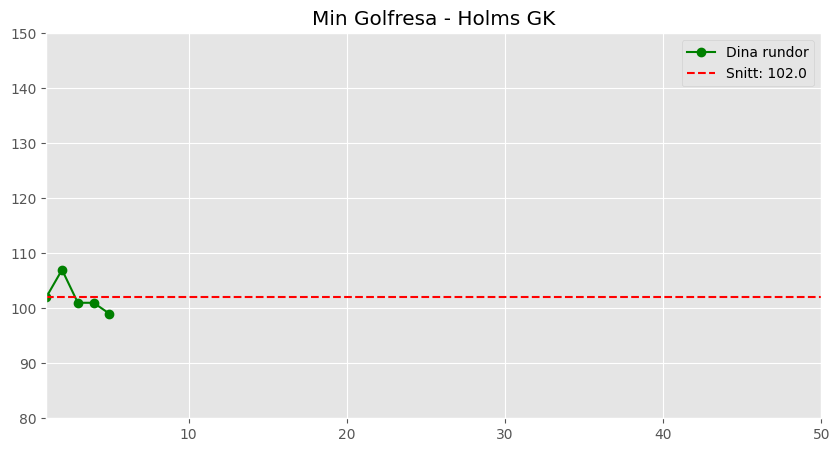

In [5]:
lagg_till_runda('2026-04-07', 'Holms GK', 'Gul', 102, 25.6)
lagg_till_runda('2026-04-11', 'Holms GK', 'Gul', 107, 25.6)
lagg_till_runda('2026-04-22', 'Holms GK', 'Gul', 101, 25.7)
lagg_till_runda('2026-05-03', 'Holms GK', 'Gul', 101, 25.6)
lagg_till_runda('2026-05-06', 'Holms GK', 'Gul', 99, 25.6)
rita_utveckling()

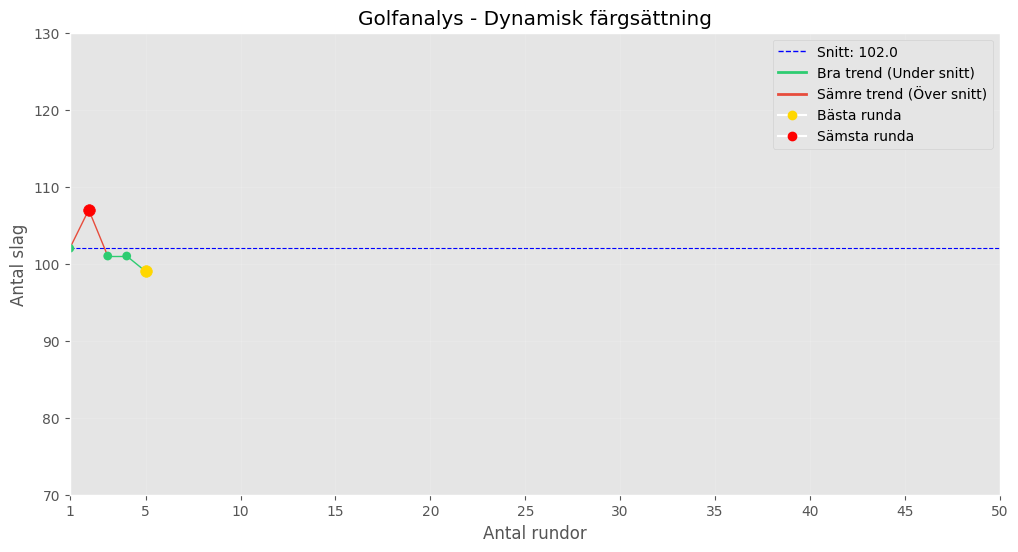

In [25]:
rita_utveckling()